In [4]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))
print(ROOT)

from database.connectie.connectie import get_engine,getData

C:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026


In [5]:
engine = get_engine()

In [16]:
df = getData(engine=engine, query="SELECT * FROM DimStock ds JOIN FactMarketData fmd on fmd.StockKey = ds.StockKey")

In [17]:
df = df.loc[:, ~df.columns.duplicated()]

In [18]:
df.shape

(26107, 9)

In [19]:
df.columns

Index(['StockKey', 'StockName', 'Type', 'DateKey', 'Close', 'High', 'Low',
       'Open', 'Volume'],
      dtype='str')

In [20]:
df.head(10)

,StockKey,StockName,Type,DateKey,Close,High,Low,Open,Volume
0,^GSPC,S&P 500,INDEX,20160104,2012.660034,2038.199951,1989.680054,2038.199951,4304880000
1,^GSPC,S&P 500,INDEX,20160105,2016.709961,2021.939941,2004.170044,2013.780029,3706620000
2,^GSPC,S&P 500,INDEX,20160106,1990.260010,2011.709961,1979.050049,2011.709961,4336660000
3,^GSPC,S&P 500,INDEX,20160107,1943.089966,1985.319946,1938.829956,1985.319946,5076590000
4,^GSPC,S&P 500,INDEX,20160108,1922.030029,1960.400024,1918.459961,1945.969971,4664940000
5,^GSPC,S&P 500,INDEX,20160111,1923.670044,1935.650024,1901.099976,1926.119995,4607290000
6,^GSPC,S&P 500,INDEX,20160112,1938.680054,1947.380005,1914.349976,1927.829956,4887260000
7,^GSPC,S&P 500,INDEX,20160113,1890.280029,1950.329956,1886.410034,1940.339966,5087030000
8,^GSPC,S&P 500,INDEX,20160114,1921.839966,1934.469971,1878.930054,1891.680054,5241110000
9,^GSPC,S&P 500,INDEX,20160115,1880.329956,1916.680054,1857.829956,1916.680054,5468460000


In [24]:
max(df['DateKey'])

20260501

In [44]:
import matplotlib.pyplot as plt

In [46]:
df['Date'] = pd.to_datetime(df['DateKey'], format='%Y%m%d')

In [48]:
df = df.sort_values(['StockKey', 'Date'])

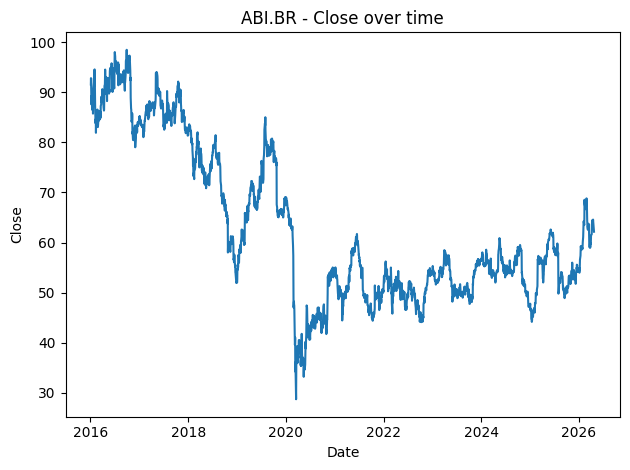

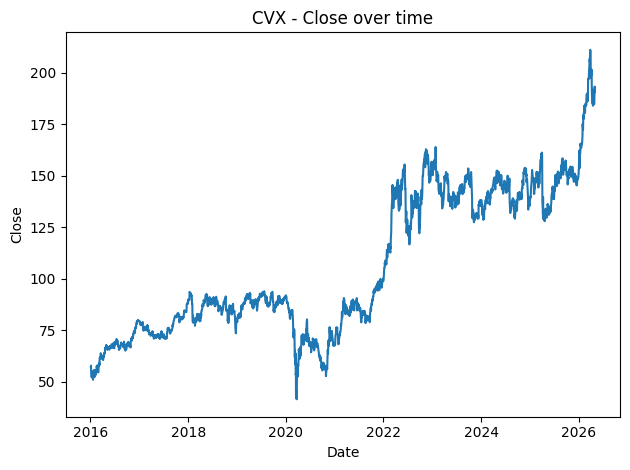

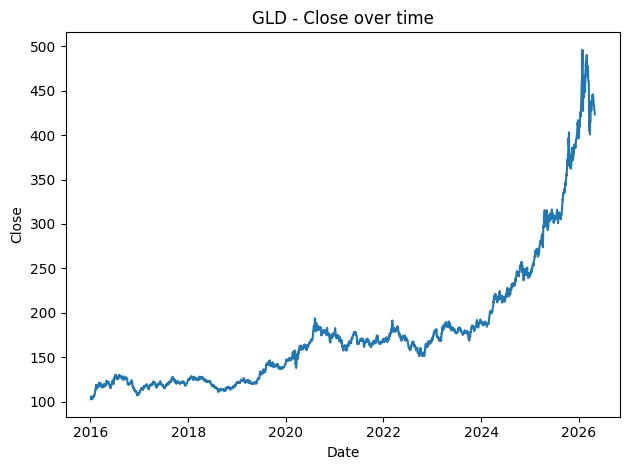

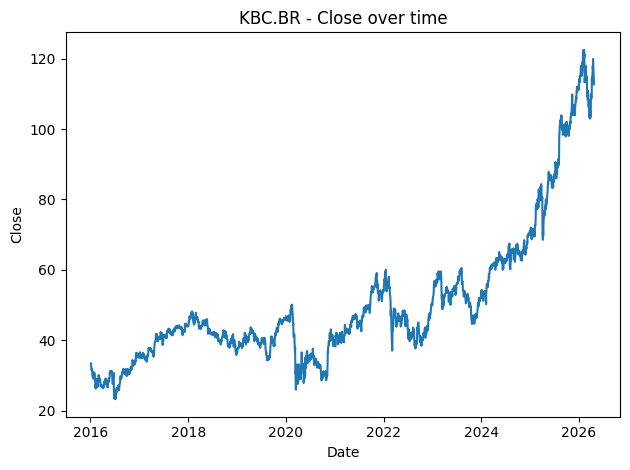

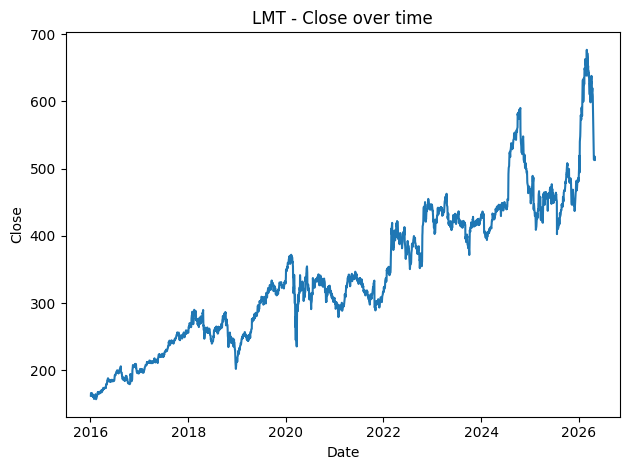

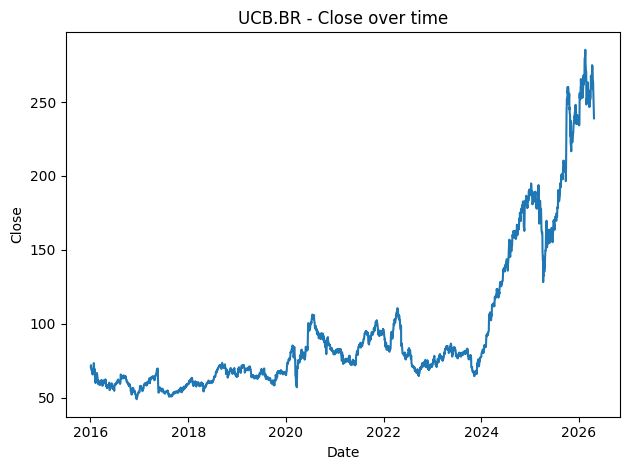

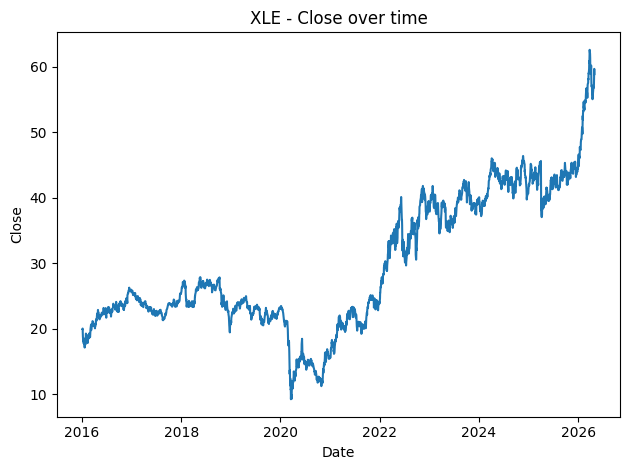

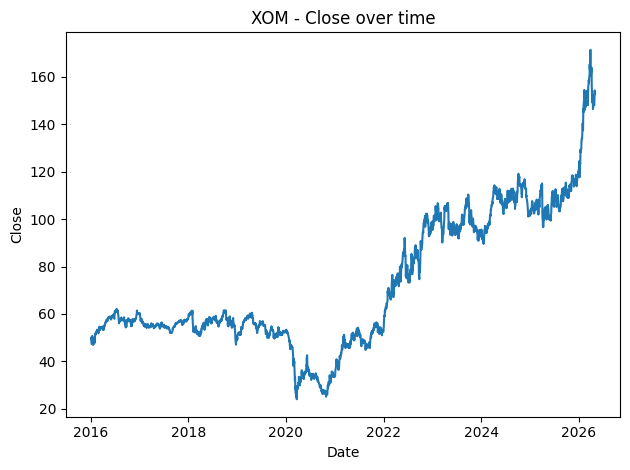

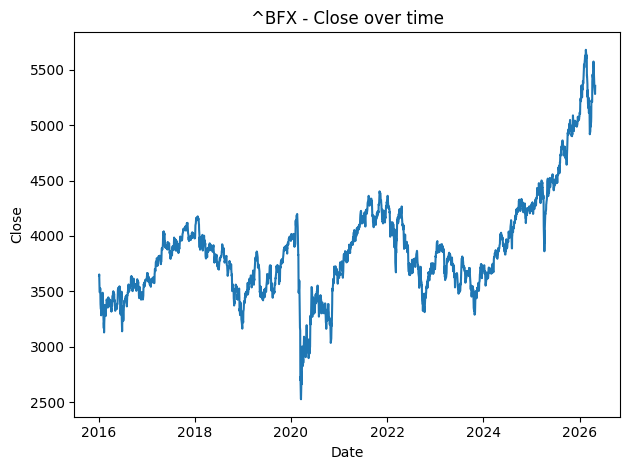

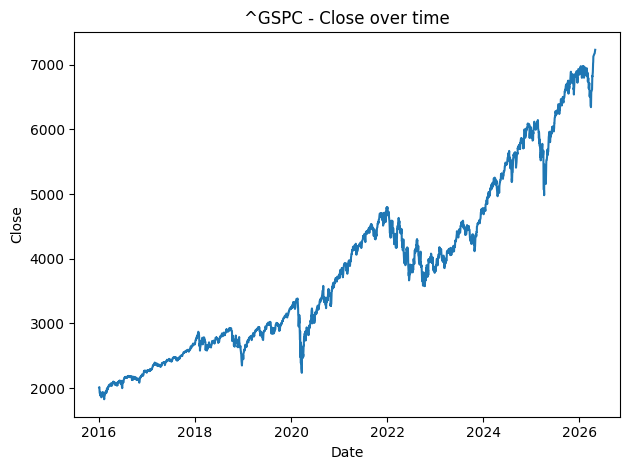

In [51]:
# per stock plotten
for key, group in df.groupby('StockKey'):
    plt.figure()
    plt.plot(group['Date'], group['Close'])
    plt.title(f'{key} - Close over time')
    plt.xlabel('Date')
    plt.ylabel('Close')
    plt.tight_layout()
    plt.show()